<a href="https://www.kaggle.com/code/ashu9990/internship-task-2?scriptVersionId=351072152" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ashu9990/datasetttt/Dataset for Data Analytics (1).xlsx


# =========================
# 1. Loading DATA
# =========================

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Load Dataset
# =========================
df = pd.read_excel("/kaggle/input/datasets/ashu9990/datasetttt/Dataset for Data Analytics (1).xlsx")
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


# =========================
# 2. Clean the data
# =========================

In [3]:
df.drop_duplicates(inplace=True)

df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.to_period("M")

df.fillna(0, inplace=True)


# =========================
# 3. Summary Statistics
# =========================

In [4]:
print(f"\nShape  →  {df.shape[0]:,} rows  ×  {df.shape[1]} columns")

print("Missing values per column:", df.isnull().sum())

print("Column data types:",df.dtypes)

print("SUMMARY STATISTICS", df.describe())


Shape  →  1,200 rows  ×  15 columns
Missing values per column: OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
Month              0
dtype: int64
Column data types: OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
Month                   period[M]
dtype: object
SUMMARY STATISTICS                       Date     Quantity    Uni

# =========================
# 4. Revenue Analysis
# =========================

In [5]:
total_revenue = df["TotalPrice"].sum()
average_order = df["TotalPrice"].mean()
highest_order = df["TotalPrice"].max()

print("TOTAL REVENUE:", total_revenue)
print("AVERAGE ORDER VALUE:", round(average_order, 2))
print("HIGHEST ORDER VALUE:", highest_order)


TOTAL REVENUE: 1264761.96
AVERAGE ORDER VALUE: 1053.97
HIGHEST ORDER VALUE: 3456.4


# =========================
# 5. Top products by revenue
# =========================


TOP 5 PRODUCTS BY REVENUE
Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Name: TotalPrice, dtype: float64


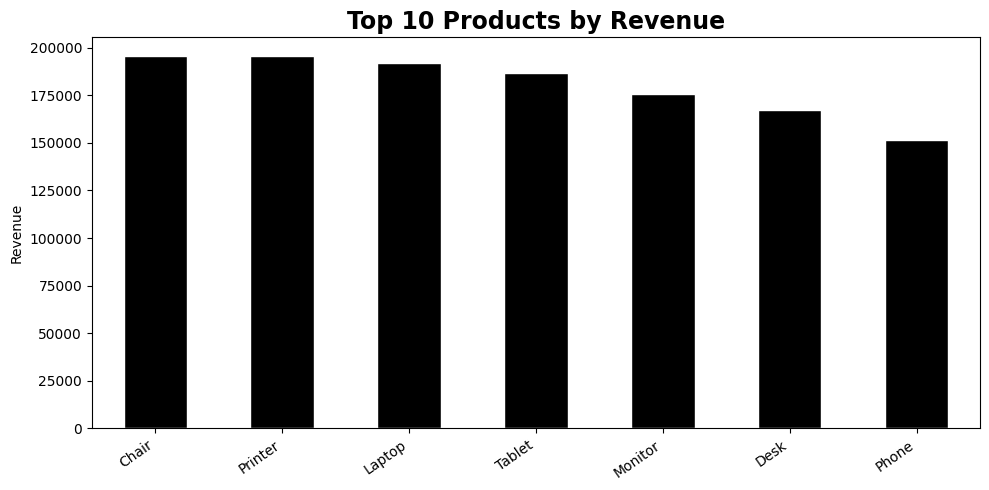

In [6]:
product_revenue = (
    df.groupby("Product")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

print("\n" + "=" * 40)
print("TOP 5 PRODUCTS BY REVENUE")
print("=" * 40)
print(product_revenue.head())

# Bar chart — top 10 products
plt.figure(figsize=(10, 5))
product_revenue.head(10).plot(kind="bar", color="black", edgecolor="white")
plt.title("Top 10 Products by Revenue", fontsize=17, fontweight="bold")
plt.ylabel("Revenue")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()



# =========================
# 6. Monthly revenue trend
# =========================

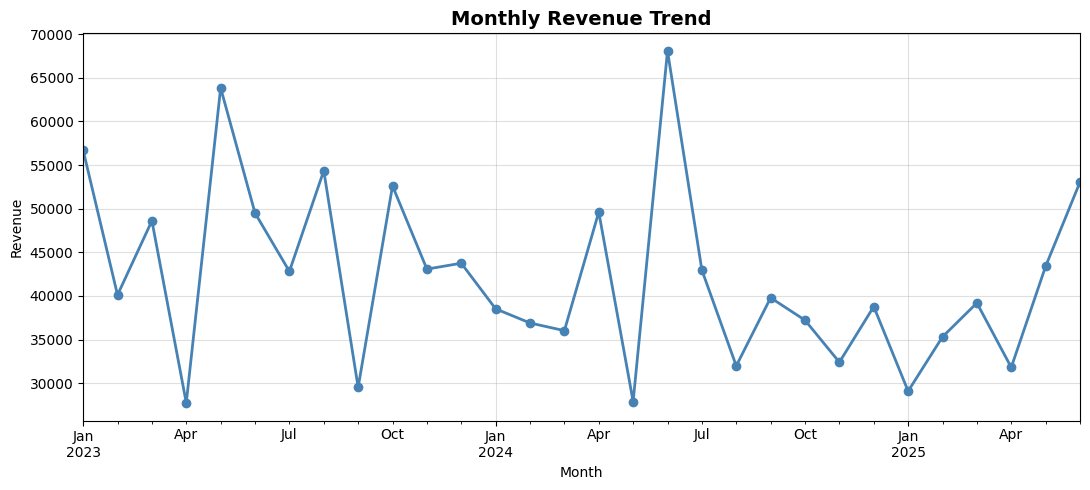

In [7]:
monthly_revenue = df.groupby("Month")["TotalPrice"].sum()
 
plt.figure(figsize=(11, 5))
monthly_revenue.plot(marker="o", color="steelblue", linewidth=2)
plt.title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# =========================
# 7. Top 10 Customers by Total Spend
# =========================


Top 10 Customers by Total Spend


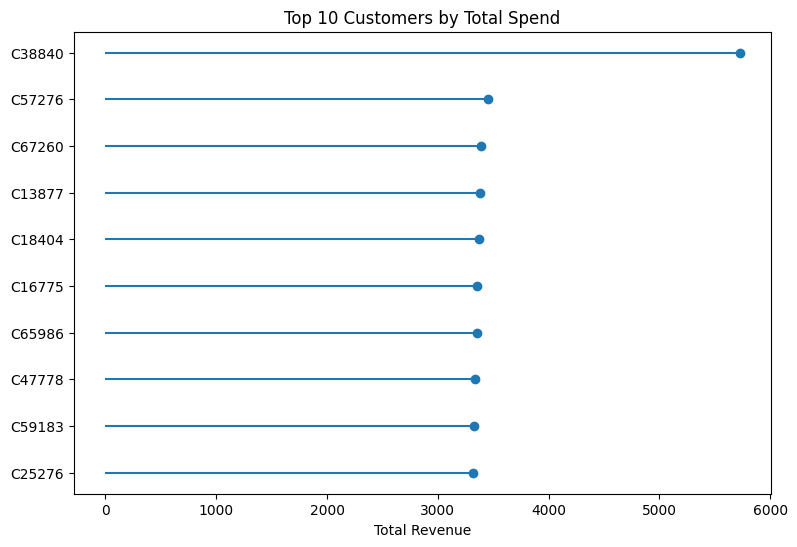

In [8]:
customer_summary = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False)

top10 = customer_summary.head(10).sort_values()

plt.figure(figsize=(9,6))

plt.hlines(y=top10.index,
           xmin=0,
           xmax=top10.values)

plt.plot(top10.values,
         top10.index,
         "o")

plt.title("Top 10 Customers by Total Spend")
plt.xlabel("Total Revenue")
print("\n" + "=" * 40)
print("Top 10 Customers by Total Spend")
print("=" * 40)
plt.show()

# =========================
# 8. Most-sold products (by quantity)
# =========================

In [9]:
if "Quantity" in df.columns:
    quantity_by_product = (
        df.groupby("Product")["Quantity"]
        .sum()
        .sort_values(ascending=False)
    )

    print("\n" + "=" * 40)
    print("MOST SOLD PRODUCTS (by quantity)")
    print("=" * 40)
    print(quantity_by_product.head())


MOST SOLD PRODUCTS (by quantity)
Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Name: Quantity, dtype: int64


# =========================
# 9. Save the top-products report
# =========================

In [10]:
output_file = "Top_Products_Report.xlsx"
product_revenue.to_excel(output_file)
print(f"Top Products report saved → {output_file}")

print("✓ Analysis completed successfully!")

Top Products report saved → Top_Products_Report.xlsx
✓ Analysis completed successfully!
